<a href="https://colab.research.google.com/github/ifarooq7/ml-with-python/blob/main/XGBoost_Disease_Diagnosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# disease diagnosis using xgboost -
# Pervaiz Khan

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Load the dataset (Pima Indians Diabetes Dataset as an example)
# You can replace this with your own medical dataset.
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

'''
Feature Engineering is the process of creating, modifying, and selecting relevant features (variables) in
 your dataset that will improve model performance


'''
# Load into a Pandas DataFrame
data = pd.read_csv(url, header=None, names=columns)




In [ ]:
# Preview the data
#print(data.head())
#print(data)
pd.set_option('display.expand_frame_repr', False)
print(data.head(30))


    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age  Outcome
0             6      148             72             35        0  33.6                     0.627   50        1
1             1       85             66             29        0  26.6                     0.351   31        0
2             8      183             64              0        0  23.3                     0.672   32        1
3             1       89             66             23       94  28.1                     0.167   21        0
4             0      137             40             35      168  43.1                     2.288   33        1
5             5      116             74              0        0  25.6                     0.201   30        0
6             3       78             50             32       88  31.0                     0.248   26        1
7            10      115              0              0        0  35.3                     0.134   29        0
8         

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [ ]:
# Setting up RandomForest and XGBoost
'''
The Model Building Process:
Choosing the Right Model: Based on problem type (regression, classification, clustering).
Splitting Data: Dividing data into training and testing sets (commonly 80-20 split).
Model Initialization: Setting up the model with default or custom hyperparameters.
Model Training: Fitting the model to the training data.
Hyperparameter Tuning: Optimizing model performance using techniques like Grid Search or Random Search.
'''

'\nThe Model Building Process:\nChoosing the Right Model: Based on problem type (regression, classification, clustering).\nSplitting Data: Dividing data into training and testing sets (commonly 80-20 split).\nModel Initialization: Setting up the model with default or custom hyperparameters.\nModel Training: Fitting the model to the training data.\nHyperparameter Tuning: Optimizing model performance using techniques like Grid Search or Random Search.\n'

In [ ]:
# Split the features and target variable

X = data.iloc[:, :-1]  # Features - iloc stands for (Integer Location.)
y = data.iloc[:, -1]   # Target (Outcome: 0 = No diabetes, 1 = Diabetes)
z = data.iloc[20:25, 0:7] # Select rows and columns. Practice function.
print(z)
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction
20            3      126             88             41      235  39.3                     0.704
21            8       99             84              0        0  35.4                     0.388
22            7      196             90              0        0  39.8                     0.451
23            9      119             80             35        0  29.0                     0.263
24           11      143             94             33      146  36.6                     0.254


In [ ]:
# Setting up randomForest
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_y_pred = rf_model.predict(X_test)
rf_y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Model Predictions:", rf_y_pred[:10])
print("Random Forest Model Prediction Probabilities:", rf_y_pred_proba[:10])

accuracy = accuracy_score(y_test, rf_y_pred)
print("Accuracy:", accuracy)

Random Forest Model Predictions: [0 0 0 0 0 1 0 1 1 1]
Random Forest Model Prediction Probabilities: [0.31 0.32 0.17 0.25 0.39 0.53 0.01 0.73 0.62 0.55]
Accuracy: 0.7207792207792207


In [ ]:
# Setting up two models with same data and compare them with A/B Testing
#A/B testing is often used to compare:
# It enables you to test different machine learning model variants in a production environment using a single endpoint.
# This kind of testing is coming build-in aws sagemaker

In [ ]:
# Setting up randomForest
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_y_pred = rf_model.predict(X_test)
rf_y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Model Predictions:", rf_y_pred[:10])
print("Random Forest Model Prediction Probabilities:", rf_y_pred_proba[:10])

accuracy = accuracy_score(y_test, rf_y_pred)
print("Accuracy:", accuracy)

Random Forest Model Predictions: [0 0 0 0 0 1 0 1 1 1]
Random Forest Model Prediction Probabilities: [0.31 0.32 0.17 0.25 0.39 0.53 0.01 0.73 0.62 0.55]
Accuracy: 0.7207792207792207


In [ ]:
# Setting up xgboost
model = xgb.XGBClassifier(objective="binary:logistic", n_estimators=50,max_depth=3,learning_rate=0.1, random_state=42)

# Train the model
model.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print (X_test)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age
668            6       98             58             33      190  34.0                     0.430   43
324            2      112             75             32        0  35.7                     0.148   21
624            2      108             64              0        0  30.8                     0.158   21
690            8      107             80              0        0  24.6                     0.856   34
473            7      136             90              0        0  29.9                     0.210   50
..           ...      ...            ...            ...      ...   ...                       ...  ...
355            9      165             88              0        0  30.4                     0.302   49
534            1       77             56             30       56  33.3                     1.251   24
344            8       95             72              0        0  36.8            

In [ ]:
# Make predictions (from the previous cell to ensure all necessary variables are available)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# probability of class 0 (e.g., No diabetes)
# probability of class 1 (e.g., Diabetes)

print(y_pred)
print(y_pred_proba)

[0 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 1 1
 0 0 1 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 0
 1 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]
[0.4063859  0.14296652 0.1325573  0.18744817 0.4181236  0.6005888
 0.01324667 0.75979686 0.63194877 0.616409   0.28053474 0.8787361
 0.2929053  0.34014907 0.03226642 0.42409495 0.13961098 0.02668366
 0.63015616 0.43956724 0.33405247 0.08979018 0.34515184 0.11787201
 0.45746744 0.93010193 0.05570386 0.02455231 0.0521908  0.16578208
 0.8265633  0.7615178  0.7963405  0.8865423  0.7553053  0.63805634
 0.90680987 0.49050564 0.4997978  0.7917174  0.04024523 0.41437837
 0.68645656 0.43008083 0.01959229 0.68586844 0.63134015 0.12082936
 0.22259495 0.9284525  0.01608806 0.7557805  0.8116072  0.15827928
 0.05082792 0.02726138 0.62195987 0.02566106 0.21655495 0.8347428
 0.6580713  0.34533

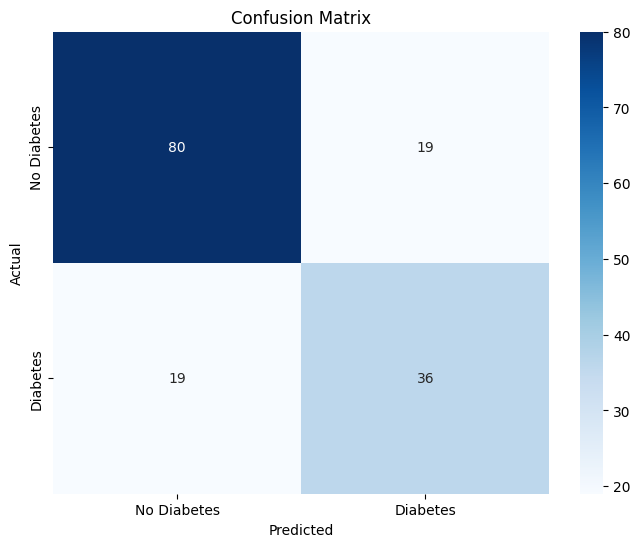

In [ ]:
# Make predictions (from the previous cell to ensure all necessary variables are available)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Draw the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]



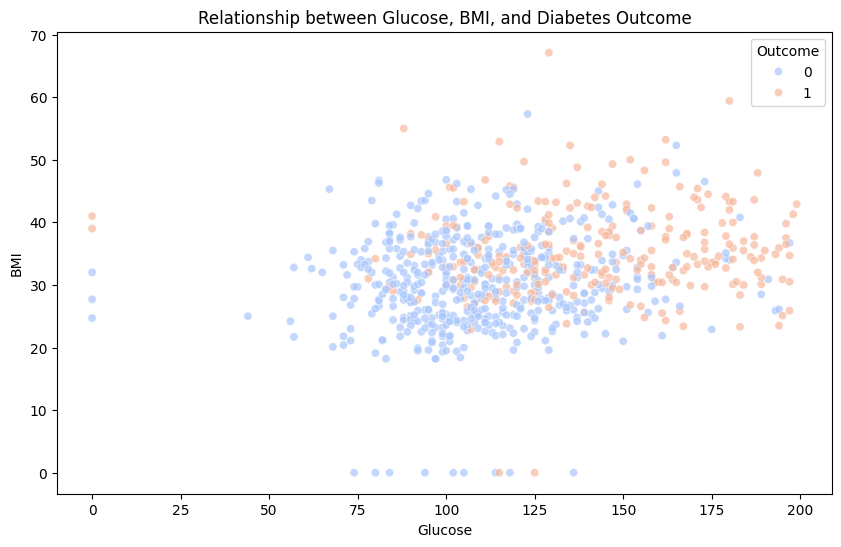

/tmp/ipython-input-575382765.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Outcome', y='Age', palette='Set2')


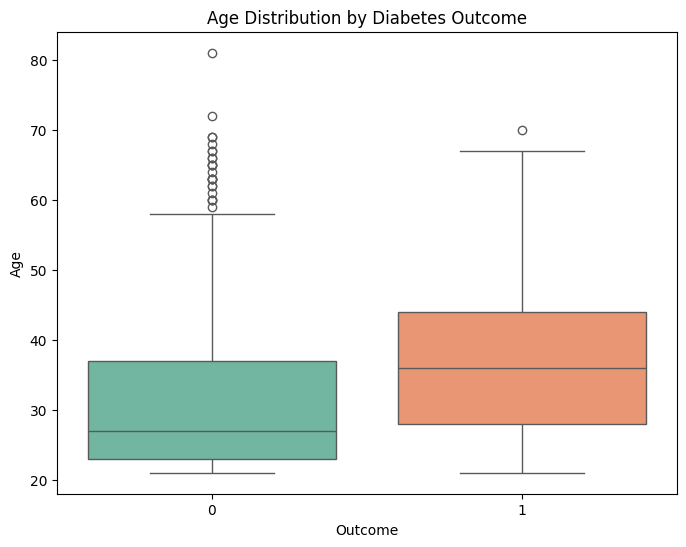

In [ ]:
# What is EDA - Exploratory Data Analysis (EDA)
'''
The next step should involve exploratory data analysis to understand the
distribution of variables, identify potential outliers or inconsistencies (e.g., zero values for BloodPressure or Glucose),
and analyze the relationships between features and the Outcome variable.
'''
# 1. Correlation Heatmap to show feature relationships
'''plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()'''

# 2. Scatter Plot: BMI vs Glucose (colored by Outcome)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Glucose', y='BMI', hue='Outcome', palette='coolwarm', alpha=0.7)
plt.title("Relationship between Glucose, BMI, and Diabetes Outcome")
plt.show()

# 3. Boxplot: Age vs Diabetes Outcome
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x='Outcome', y='Age', palette='Set2')
plt.title("Age Distribution by Diabetes Outcome")
plt.show()


In [ ]:
'''
Accuracy: Percentage of correctly predicted labels.
Precision: Percentage of correctly predicted positive observations.
Recall (Sensitivity): Percentage of actual positives correctly identified.
F1-Score: Harmonic mean of precision and recall.
ROC-AUC Score: Measures the model’s ability to distinguish between classes

'''

Accuracy: 0.7532467532467533

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


F1-score: 0.6545


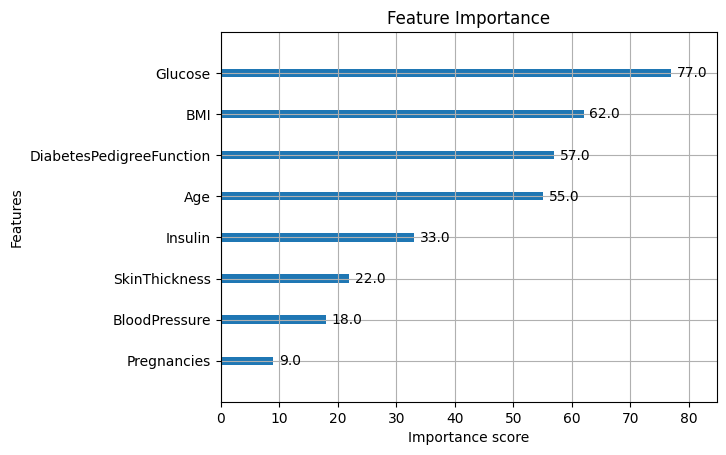

In [ ]:
# Evaluate accuracy
# Accuracy=TP+TN/+FP+FN+TP+TN​

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Generate a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Compute ROC AUC Score
#roc_auc = roc_auc_score(y_test, y_pred_proba)
#print("ROC AUC Score:", roc_auc)

# Calculate F1-score
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"\nF1-score: {f1:.4f}")

# Plot feature importance
import matplotlib.pyplot as plt

xgb.plot_importance(model, importance_type="weight")
plt.title("Feature Importance")
plt.show()

In [ ]:
# Create Deployable artifacts.
# Below code is creating pickle file


In [ ]:
import joblib
import xgboost as xgb

# Re-initialize and train the XGBoost model to ensure it's defined
# (assuming X_train and y_train are available from previous executions)
model = xgb.XGBClassifier(objective="binary:logistic", n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Save the XGBoost model
joblib.dump(model, 'xgboost_diabetes_model.pkl')

print("XGBoost model saved as xgboost_diabetes_model.pkl")

XGBoost model saved as xgboost_diabetes_model.pkl


## Summary:

### Data Analysis Key Findings

*   The "Pima Indians Diabetes Dataset" was successfully loaded into a Pandas DataFrame named `data` from the specified URL: `https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv`.
*   The dataset contains 768 entries (rows) and 9 columns: `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, and `Outcome`.
*   All columns have appropriate numerical data types; specifically, `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `Age`, and `Outcome` are `int64`, while `BMI` and `DiabetesPedigreeFunction` are `float64`.
*   There are no missing values in any of the columns, as indicated by all columns showing 768 non-null entries.

### Insights or Next Steps

*   The dataset is clean regarding missing values, which streamlines the initial data preparation phase.
*   The next step should involve exploratory data analysis to understand the distribution of variables, identify potential outliers or inconsistencies (e.g., zero values for `BloodPressure` or `Glucose`), and analyze the relationships between features and the `Outcome` variable.


The trained XGBoost model has been saved as `xgboost_diabetes_model.pkl`. This file can now be used to deploy the model for making new predictions.